In [3]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend, plot, show, title, xlabel,ylabel
import pandas as pd
import numpy as np

In [ ]:
# Bar chart
# The different bars in the bar chart will not each other and would be of equal thickness.

In [3]:
states = ["KA","MH","AP","MP","UP"]
counts = [40, 35, 50, 20, 15]

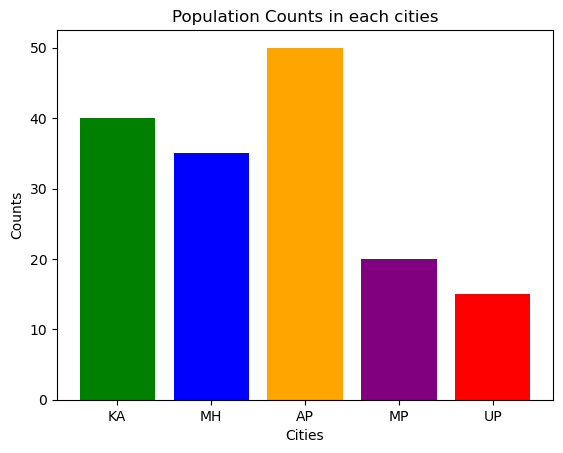

In [12]:
plt.bar(states,counts, color = ["green","blue","orange","purple","red"])
plt.title("Population Counts in each cities")
plt.xlabel("Cities")
plt.ylabel("Counts")
plt.show()

In [15]:
df = pd.read_excel("CDAC_DataBook.xlsx", sheet_name="ERPData")
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [16]:
df1 = df.MaterialID.value_counts()
df1

MaterialID
TMI-43T    15
AXCP-78    11
DDBN-89     8
SDRT-67     6
GCVB-79     5
LXCV-21     5
Name: count, dtype: int64

<BarContainer object of 6 artists>

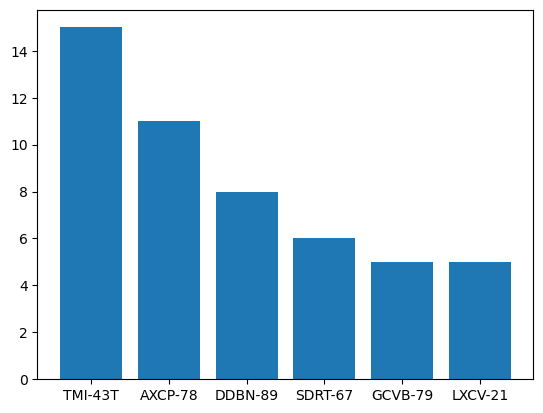

In [22]:
plt.bar(df1.index, df1)

In [43]:
x = df.groupby(df.MaterialID).Quantity.agg(sum)
x

/tmp/ipykernel_4903/4264038246.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  x = df.groupby(df.MaterialID).Quantity.agg(sum)


MaterialID
AXCP-78    898
DDBN-89    383
GCVB-79    182
LXCV-21    243
SDRT-67    294
TMI-43T    885
Name: Quantity, dtype: int64

<BarContainer object of 6 artists>

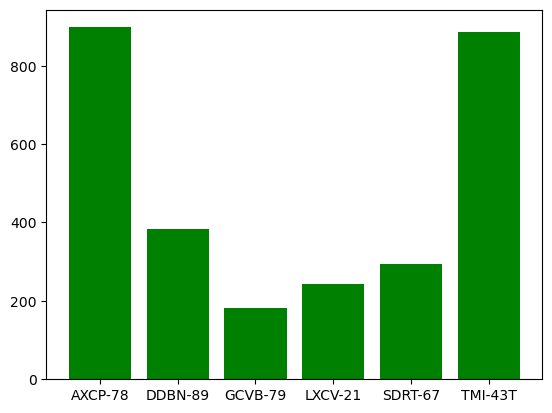

In [64]:
plt.bar(x.index, x, color="green")

<Axes: >

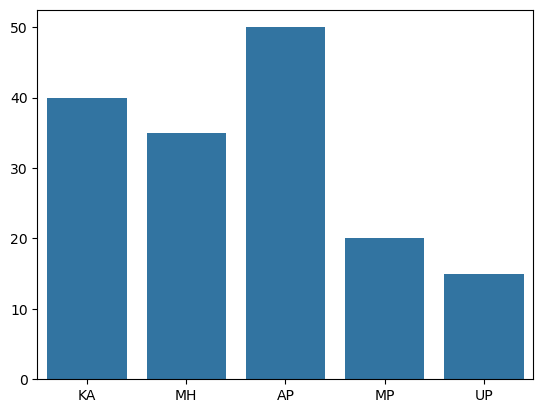

In [58]:
sns.barplot(x=states, y=counts) # Seaborn

<Axes: xlabel='Location'>

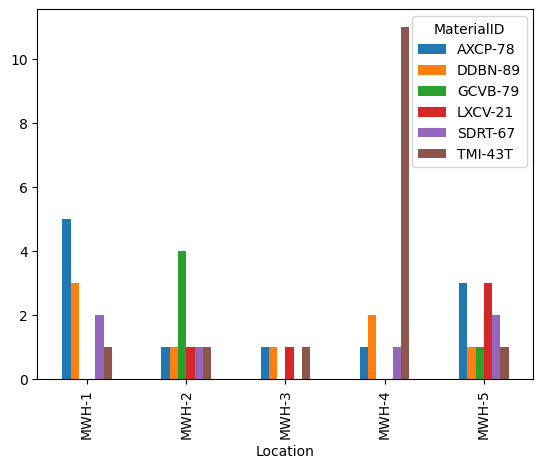

In [79]:
df1 = pd.crosstab(df.Location, df.MaterialID)
df1.plot(kind="bar")

In [80]:
# For each combination what proportion has weight more than 70.

In [82]:
df = pd.read_excel("CDAC_DataBook.xlsx", sheet_name="nominal")
df.head()

,ses,write,math,prog
0,1,35,41,1
1,2,33,41,2
2,3,39,44,3
3,1,37,42,1
4,2,31,40,2


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ses     200 non-null    int64
 1   write   200 non-null    int64
 2   math    200 non-null    int64
 3   prog    200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


<Axes: xlabel='ses'>

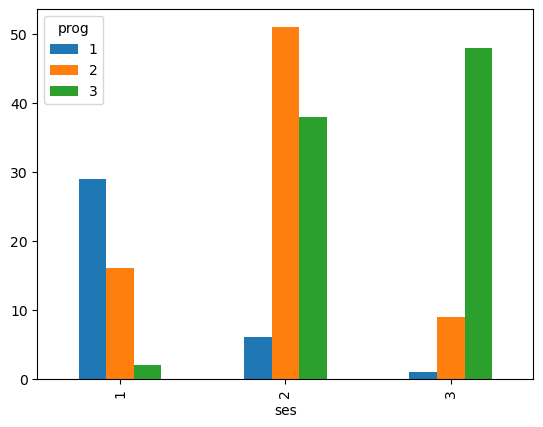

In [92]:
# Effect of categorical data on another categorical data (Grouped-bar chart)
df1 = pd.crosstab(df.ses, df.prog)
df1.plot(kind = "bar")

In [51]:
df = pd.read_excel("CDAC_DataBook.xlsx", sheet_name="ERPData")
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


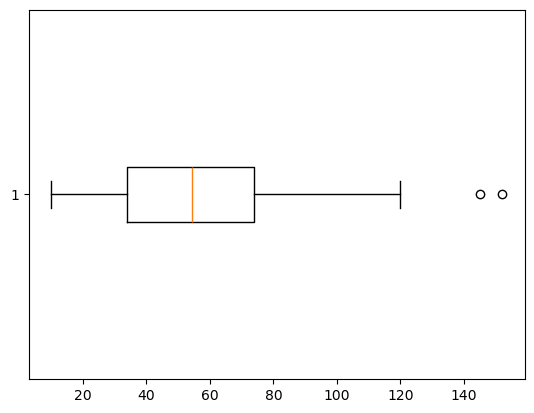

In [96]:
plt.boxplot(df.Quantity, vert=False)
plt.show()

<Axes: ylabel='Quantity'>

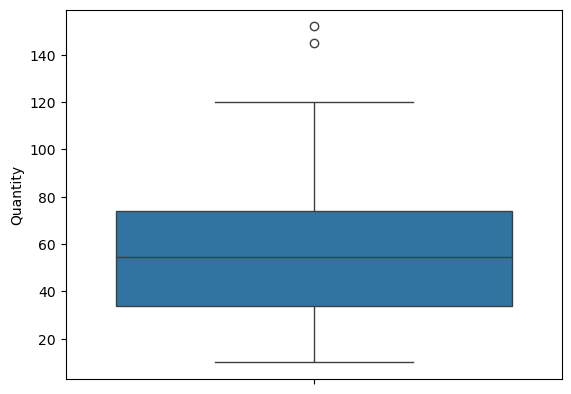

In [54]:
sns.boxplot(df.Quantity)

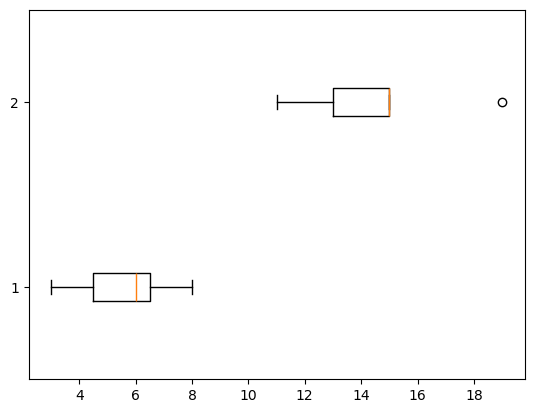

In [56]:
# Effect of categorical data on continuous data
male_sal = [4,6,5,3,7,6,8]
female_sal = [11,15,13,19,15]
plt.boxplot([male_sal,female_sal], vert=False)
plt.show()

<Axes: >

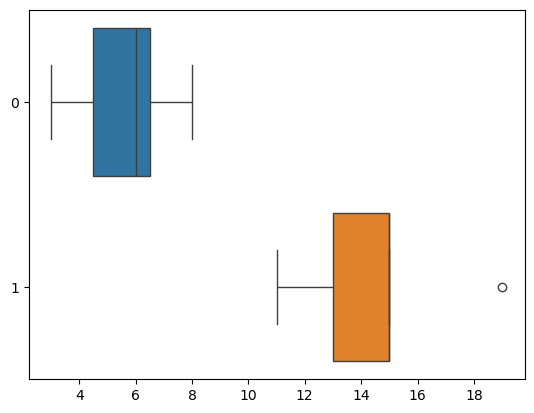

In [65]:
sns.boxplot([male_sal, female_sal], orient="h")

In [ ]:
# Situation 1: Single categorical data (Simple bar chart) : Type of scale (Nominal or ordinal)
# Situation 2: Effect of one categorical data on another categorical data (Grouped bar chart)
# Situation 3: Single Continuous data. (Histogram) (x axis variable is continous data so the bars will touch each other)
# Situation 4: Effect of one continuous data on another continuous data (Scatter plot)

In [3]:
df = pd.read_excel("CDAC_DataBook.xlsx", sheet_name="ERPData")
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


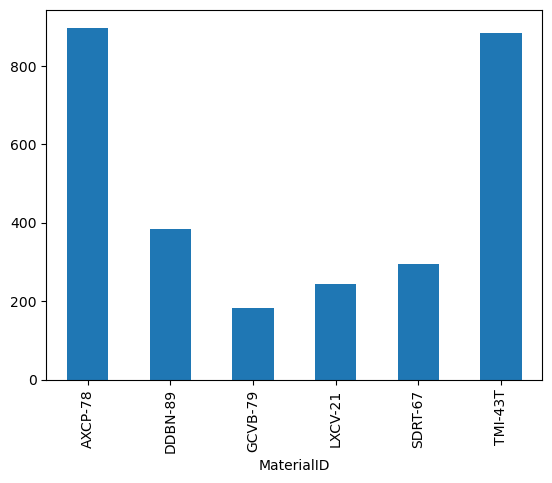

In [6]:
# Single categorical data (Bar chart)
df.groupby("MaterialID").Quantity.agg("sum").plot(kind="bar")
plt.show()

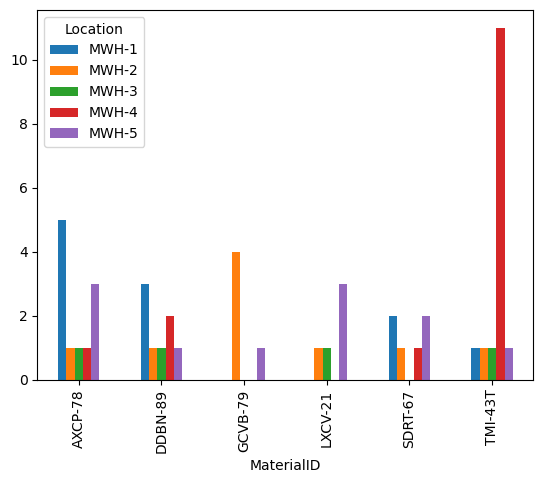

In [7]:
# Effect of one categorical data on another categorical data (Grouped bar chart)
# For Counts
pd.crosstab(df.MaterialID,df.Location).plot(kind="bar")
plt.show()

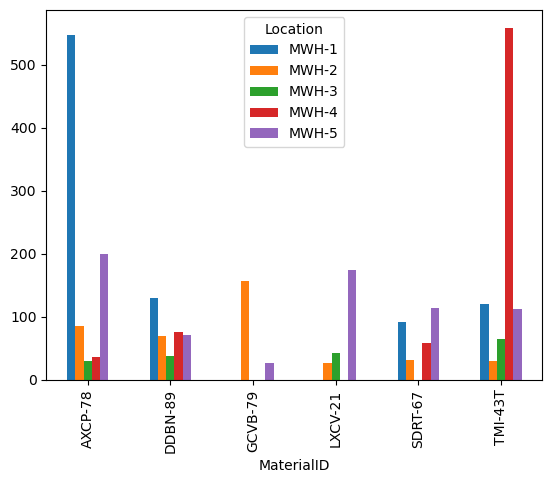

In [9]:
# For total quantity
pd.crosstab(df.MaterialID,df.Location, values=df.Quantity, aggfunc="sum").plot(kind="bar")
plt.show()

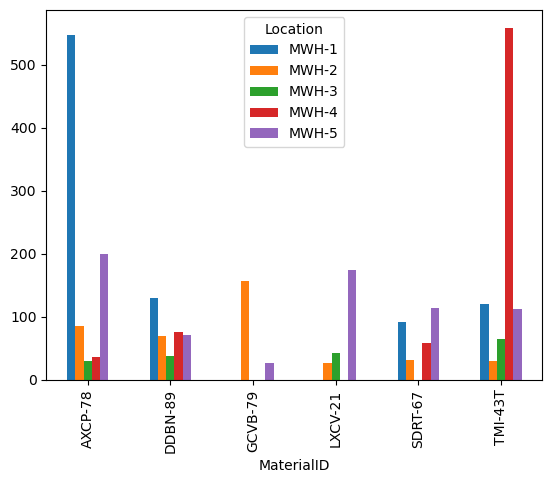

In [52]:
# Using pivot_table (Matplotlib)
df.pivot_table(values="Quantity", index="MaterialID", columns="Location", aggfunc="sum").plot(kind="bar")
plt.show()

<Axes: xlabel='MaterialID', ylabel='Quantity'>

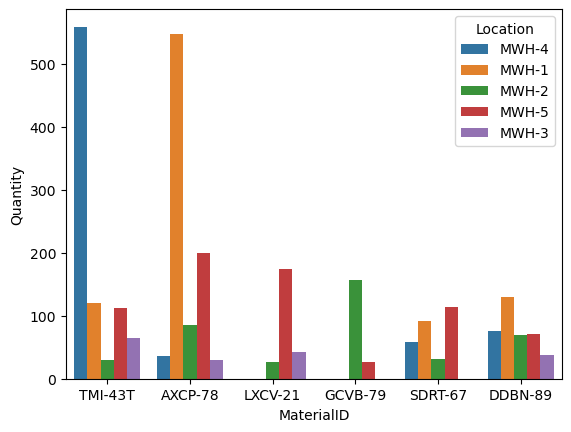

In [53]:
# Using seaborn
sns.barplot(x="MaterialID", y="Quantity",hue="Location", data=df, errorbar=None, estimator=np.sum)

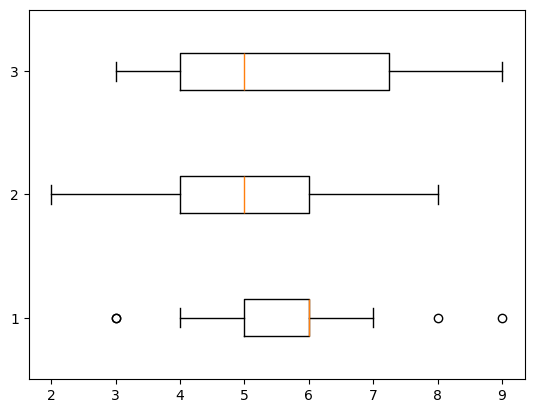

In [15]:
# Effect of categorical data on the continuous data (or effect of continuous data on the categorical data)
x1 = [5,6,4,3,5,6,7,8,9,6,6,3,6]
x2 = [3,5,4,5,6,7,6,5,4,5,6,7,8,2,3]
x3 = [4,5,3,4,5,7,8,9,4,3,6,8]
plt.boxplot([x1,x2,x3], vert=False)
plt.show()

(array([2., 1., 0., 2., 0., 5., 1., 0., 1., 1.]),
 array([3. , 3.6, 4.2, 4.8, 5.4, 6. , 6.6, 7.2, 7.8, 8.4, 9. ]),
 <BarContainer object of 10 artists>)

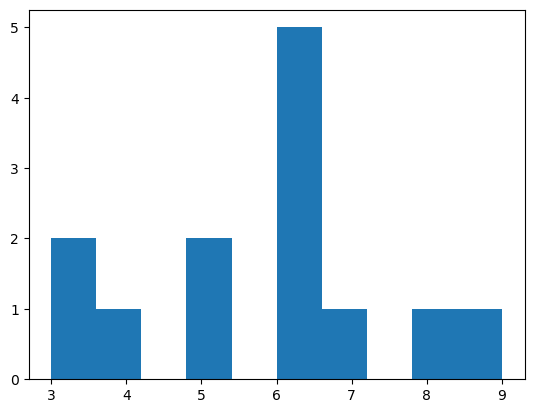

In [18]:
plt.hist(x1)

In [66]:
df = pd.read_excel("CDAC_DataBook.xlsx", sheet_name="faithful")
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


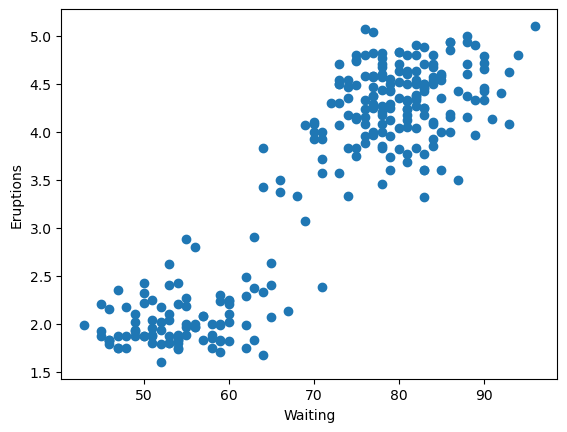

In [27]:
plt.scatter(df.waiting, df.eruptions)
plt.xlabel("Waiting")
plt.ylabel("Eruptions")
plt.show()

<Axes: xlabel='waiting', ylabel='eruptions'>

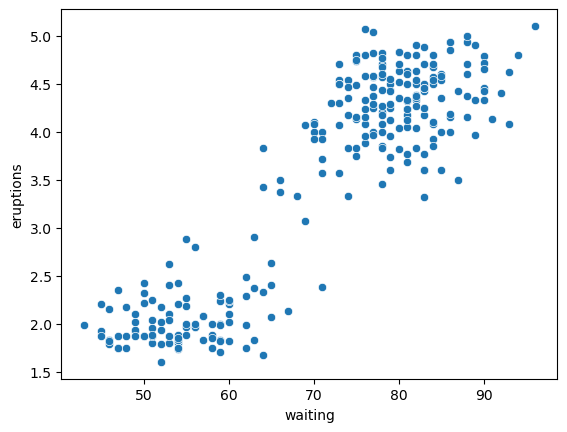

In [69]:
sns.scatterplot(data = df,x="waiting",y="eruptions")

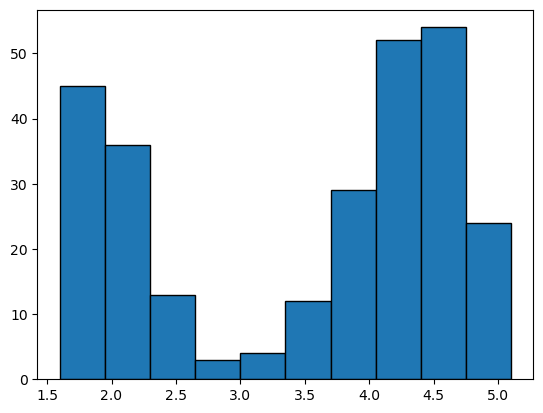

In [33]:
cats = [1.5,2.1,3.5,4.2,5.2]
plt.hist(df.eruptions, edgecolor="black")
plt.show()

<Axes: xlabel='eruptions', ylabel='Count'>

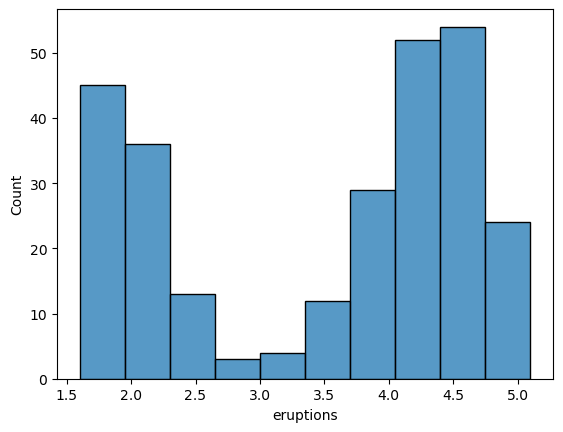

In [34]:
sns.histplot(df.eruptions)

In [ ]:
# Types of analysis in EDA
# 1. Univariate analysis (Uni-> One, variate->variable)
# 2. Bivariate analysis
# 3. Multivariate analysis

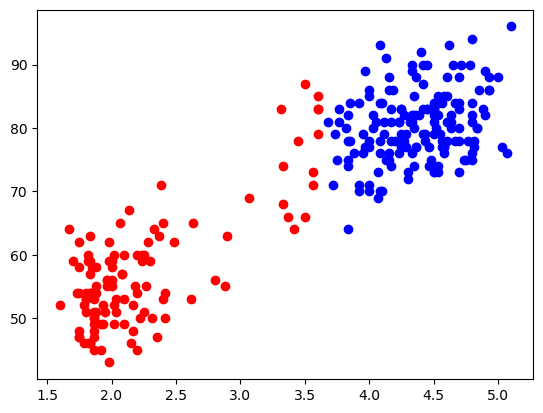

In [37]:
# Grouped Scatter plot (Continuous data with continuous data)
df1 = df.iloc[np.where(df.eruptions<=3.6)]
df2 = df.iloc[np.where(df.eruptions>3.6)]

plt.scatter(df1.eruptions, df1.waiting, c="red")
plt.scatter(df2.eruptions, df2.waiting, c="blue")
plt.show()

In [39]:
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


<BarContainer object of 3 artists>

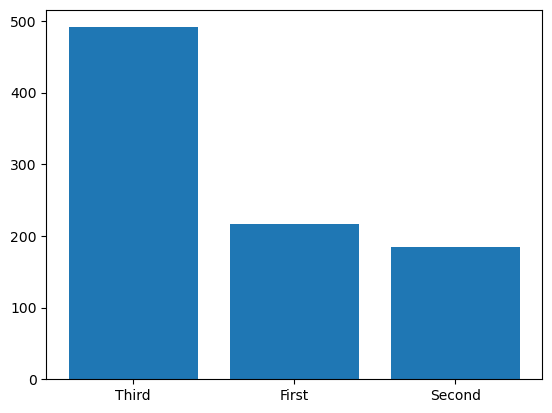

In [43]:
class_counts = df['class'].value_counts()
plt.bar(class_counts.index, class_counts.values)

<Axes: xlabel='class', ylabel='fare'>

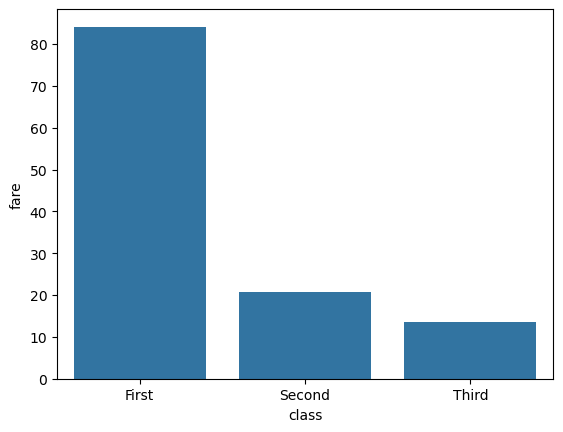

In [48]:
sns.barplot(x='class', y='fare', data=df, errorbar=None)

<Axes: ylabel='Count'>

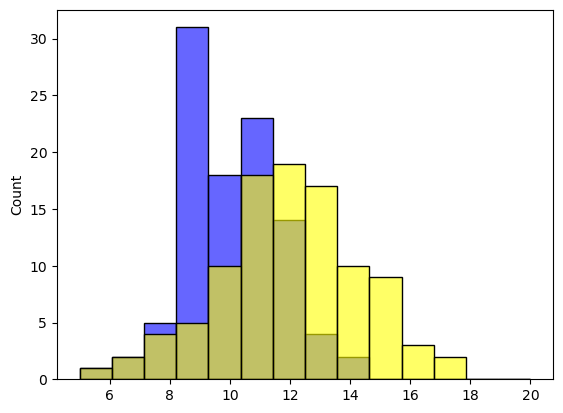

In [71]:
# Group histogram:
group1 = np.random.normal(loc=10, scale=2, size=100)  # Volcano A mean is 10 and std dev=2
group2 = np.random.normal(loc=12, scale=2.5, size=100)  # e.g., Volcano B

bins = np.linspace(5, 20, 15)  # common bin edges for both groups

sns.histplot(group1, bins=bins, alpha=0.6, label='Volcano A', color='blue', edgecolor='black')
sns.histplot(group2, bins=bins, alpha=0.6, label='Volcano B', color='yellow', edgecolor='black')
# plt.show()

In [74]:
df = pd.read_excel("ManHours.xlsx")
df.head()

,Name,Client,Hours,Grade,Team
0,A,CDAC,3,A,2
1,B,CDAC,4,A,2
2,A,Infy,2,B,1
3,C,Infy,4,C,3
4,A,CDAC,3,A,2


In [124]:
df = pd.read_csv("6-Churn_ModellingDataSet.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [127]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [134]:
exit_counts = df.Exited.value_counts()
exit_counts

Exited
0    7963
1    2037
Name: count, dtype: int64

In [135]:
exit_prop = pd.DataFrame(exit_counts)
exit_prop

,count
Exited,
0,7963
1,2037


In [137]:
exit_prop['proportion'] = exit_prop['count']/sum(exit_prop['count'])
exit_prop

,count,proportion
Exited,,
0,7963,0.7963
1,2037,0.2037


In [ ]:
# Does the salary has any effect on exited or not

In [138]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [125]:
df1=df.iloc[np.where(df.Exited==1)]

In [128]:
grp1 = df1.groupby(df.Geography)
x1 = grp1.Exited.sum()

In [129]:
x1.reset_index()

,Geography,Exited
0,France,810
1,Germany,814
2,Spain,413


In [ ]:
plt.box

In [4]:
# Data Skewness
x1 = np.repeat([1,2,3,4,5,6,7,8,9,10],[5,10,150,140,120,100,80,60,40,20])

(array([  5.,  10., 150., 140., 120., 100.,  80.,  60.,  40.,  20.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

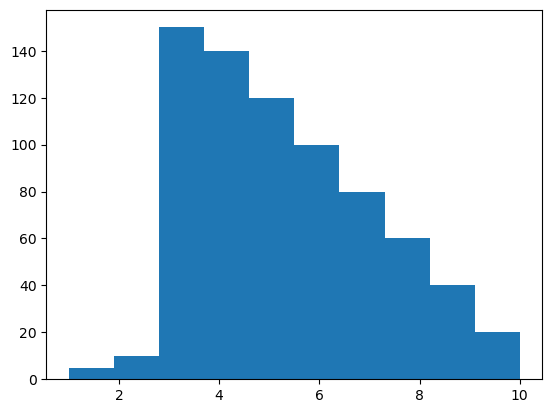

In [6]:
plt.hist(x1)

In [8]:
import scipy
from scipy import stats
scipy.stats.skew(x1)

np.float64(0.48916996679169206)

In [ ]:
# In case where peak is in the left side, the mean>median>mode

(array([ 20.,  40.,  60.,  80., 100., 120., 140., 150.,  10.,   5.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

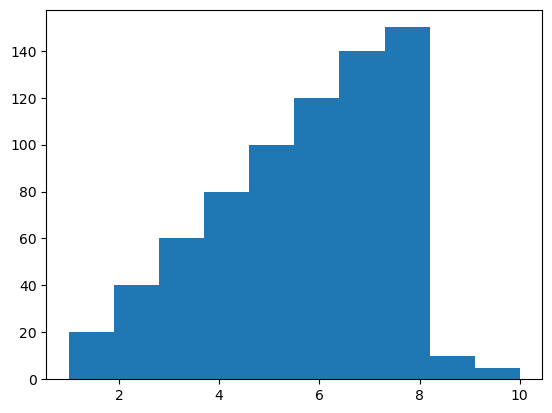

In [9]:
x2 = np.repeat([1,2,3,4,5,6,7,8,9,10],[20,40,60,80,100,120,140,150,10,5])
plt.hist(x2)

In [10]:
scipy.stats.skew(x2)

np.float64(-0.48916996679169217)

In [11]:
# sum((x1-xbar)**3)/(n-1)*sd**3 -- (x1-xbar)**3 is the third moment of mean --(x1-xbar)**2 is the second moment of the mean

(array([  5.,  10.,  15.,  20., 400.,  20.,  15.,  10.,   5.,   2.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

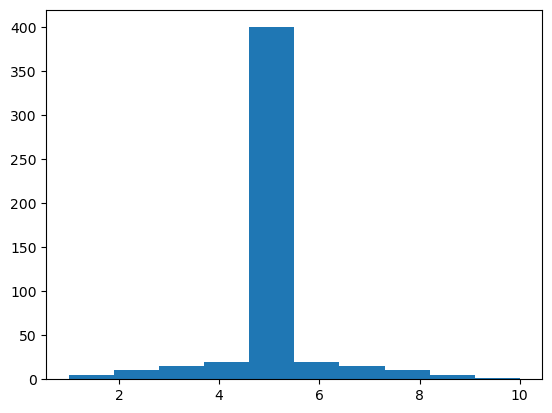

In [12]:
# Kurtosis
# Leptokurtic
x1 = np.repeat([1,2,3,4,5,6,7,8,9,10],[5,10,15,20,400,20,15,10,5,2])
plt.hist(x1)

In [13]:
scipy.stats.kurtosis(x1)

np.float64(6.850298487712665)

(array([20., 25., 25., 30., 35., 30., 25., 25., 20., 20.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

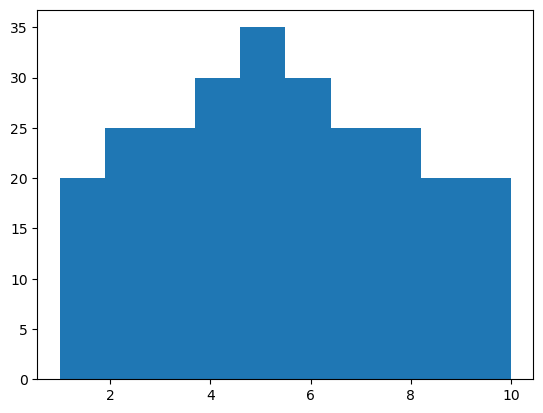

In [14]:
# Platykurtic
x2 = np.repeat([1,2,3,4,5,6,7,8,9,10],[20,25,25,30,35,30,25,25,20,20])
plt.hist(x2)

In [15]:
scipy.stats.kurtosis(x2)

np.float64(-1.0233152049490384)

(array([ 2.,  5., 10., 20.,  0., 30., 20., 10.,  5.,  2.]),
 array([1. , 1.8, 2.6, 3.4, 4.2, 5. , 5.8, 6.6, 7.4, 8.2, 9. ]),
 <BarContainer object of 10 artists>)

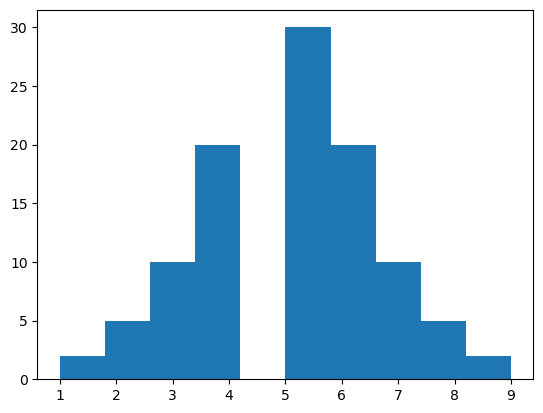

In [18]:
# Mesokurtic
x3 = np.repeat([1,2,3,4,5,6,7,8,9],[2,5,10,20,30,20,10,5,2])
plt.hist(x3)

In [25]:
scipy.stats.kurtosis(x3)

np.float64(0.03926687623208469)

In [23]:
# Formula for kurtosis:- sum((x1-x1bar)**4)/(n*sd**4)
# Excess kurtosis:- sum((x1-x1bar)**4)/(n*sd**4) -3
# Python by default gives excess kurtosis

In [ ]:
# Corelation of coefficient:- 
# 1. The value of corelation coefficient is always between +1 and -1. 
# 2. The sign indicates the type of relationship and the magnitude indicates the strength of relationship

In [26]:
df = pd.read_excel("CDAC_DataBook.xlsx", sheet_name='stackloss')
df.head()

,AirFlow,WaterTemp,AcidConc,StackLoss
0,80,27,89,42
1,80,27,88,37
2,75,25,90,37
3,62,24,87,28
4,62,22,87,18


In [27]:
df.corr()

,AirFlow,WaterTemp,AcidConc,StackLoss
AirFlow,1.000000,0.781852,0.500143,0.919663
WaterTemp,0.781852,1.000000,0.390940,0.875504
AcidConc,0.500143,0.390940,1.000000,0.399830
StackLoss,0.919663,0.875504,0.399830,1.000000


<Axes: >

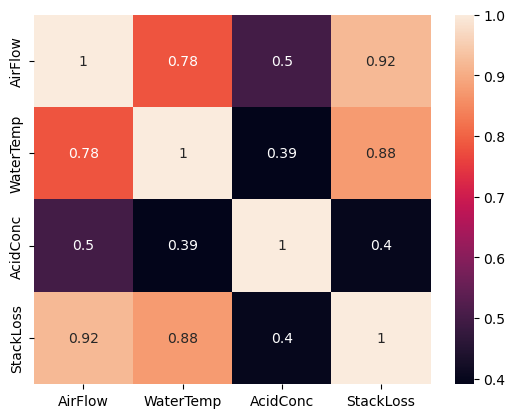

In [31]:
sns.heatmap(df.corr(),annotannot=True=True)